<a href="https://colab.research.google.com/github/EmilyHong77/degentrificAItion/blob/main/model_training_Emilie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

file_name_all = '/content/drive/MyDrive/GentrificAItion/Montreal_data_from_census/Standardized_Census_Data/census_data_ding.csv'
file_name_train = '/content/drive/MyDrive/GentrificAItion/ModelOutputs/features_train.csv'
file_name_predict = '/content/drive/MyDrive/GentrificAItion/ModelOutputs/features_test.csv'

# REPLACE FILE_NAME
file_name = file_name_train

# Replace 'your_dataset.csv' with your actual dataset file path
df = pd.read_csv(file_name)

# Convert non-numeric values to NaN in each column
columns_to_convert = df.keys()
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values with the average
for col in columns_to_convert:
    average_value = df[col].mean()
    df[col].fillna(average_value, inplace=True)

# Convert specific columns to float
df[columns_to_convert] = df[columns_to_convert].astype(float)

if file_name == file_name_all:
  column_name = "Population percentage change, 2001-2006 2006"
  # Calculate the average of non-inf values
  average_without_inf = df.loc[~df[column_name].isin([np.inf, -np.inf]), column_name].mean()
  # Replace inf values with the calculated average
  df['Population percentage change, 2001-2006 2006'].replace([np.inf, -np.inf], average_without_inf, inplace=True)

# Display the first few rows of the dataset
print(df.head())

       ctuid  50 to 59 years 2001  All others 2001  \
0       -1.0                  0.0              0.0   
1  4620001.0                 40.0           2180.0   
2  4620002.0                140.0           2275.0   
3  4620002.0                140.0           2275.0   
4  4620003.0                135.0           5435.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                              290.0           
2                                              270.0           
3                                              270.0           
4                                              510.0           

   Average gross rent 2001  Average value dwelling 2001  \
0                      0.0                          0.0   
1                    440.0                        440.0   
2                    435.0                        435.0   
3                    435.0                        435.

In [ ]:
'''
# Check for inf values in the entire DataFrame
inf_values = data.isin([float('inf'), float('-inf')])

# Check if any column contains inf values
inf_in_columns = inf_values.any()

# Check if any row contains inf values
inf_in_rows = inf_values.any(axis=1)

# Print columns containing inf values
print("Columns containing inf values:")
print(inf_in_columns[inf_in_columns])

# Print rows containing inf values
print("\nRows containing inf values:")
print(data[inf_in_rows])
'''

'\n# Check for inf values in the entire DataFrame\ninf_values = data.isin([float(\'inf\'), float(\'-inf\')])\n\n# Check if any column contains inf values\ninf_in_columns = inf_values.any()\n\n# Check if any row contains inf values\ninf_in_rows = inf_values.any(axis=1)\n\n# Print columns containing inf values\nprint("Columns containing inf values:")\nprint(inf_in_columns[inf_in_columns])\n\n# Print rows containing inf values\nprint("\nRows containing inf values:")\nprint(data[inf_in_rows])\n'

# 1 Find Important Predictors of Gentrification

In [3]:
# specificy which columns to drop depending on what target is

# predict Gentrifiable
Gentrifiable_2021 = ["ctuid",
                     "Median total income of household in 2020 ($) 2021",
                     "Gentrified Ding 2021",
                     "Gentrified Ding 2021",
                     "Median after-tax income of household in 2020 ($) 2021"]

# predict Gentrified
Gentrified_2021 = ["ctuid",
                   "Average value of dwellings ($) 2021",
                   "Median monthly shelter costs for rented dwellings ($) 2021",
                   "Bachelor's degree or higher 2021",
                   "Gentrification Level Ding 2021"
                   ]

# predict Gentrification Level
Gen_Levels_2021 = ["ctuid",
                   "Average value of dwellings ($) 2021",
                   "Median monthly shelter costs for rented dwellings ($) 2021",
                   "Bachelor's degree or higher 2021",
                   "Gentrified Ding 2021"
                   ]

# Specify columns we wish the model to predict
target_column_gentrifiable_2021 = "Gentrifiable Ding 2021"
target_column_gentrified_2021 = "Gentrified Ding 2021"
target_column_gen_levels_2021 = "Gentrification Level Ding 2021"

In [4]:
# drop the column that is your target
# df_1 = df.drop(Gentrifiable_2021, axis=1)
# df_1 = df.drop(Gentrified_2021, axis=1)
df_1 = df.drop(Gen_Levels_2021, axis=1)

# Specify which column we wish the model to predict
# target_column, num_class = target_column_gentrifiable_2021, 2
# target_column, num_class = target_column_gentrified_2021, 2
target_column, num_class = target_column_gen_levels_2021, 4

# Define features and target
X = df_1.drop(target_column, axis=1)
y = df_1[target_column]
print(y)

0       0.0
1       2.0
2       0.0
3       0.0
4       0.0
       ... 
1003    0.0
1004    0.0
1005    0.0
1006    0.0
1007    0.0
Name: Gentrification Level Ding 2021, Length: 1008, dtype: float64


In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix (XGBoost's internal data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters
params = {
    'objective': 'multi:softprob',  # Specify multiclass classification
    'num_class': num_class,  # NUMBER OF CLASSES = 4 for Level of gentrification; 2 for others
    'eval_metric': 'mlogloss',  # Evaluation metric
    'max_depth': 4,  # Maximum depth of a tree
    'eta': 0.3,  # Learning rate
    'seed': 42  # Random seed for reproducibility
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions
y_pred_prob = bst.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.81


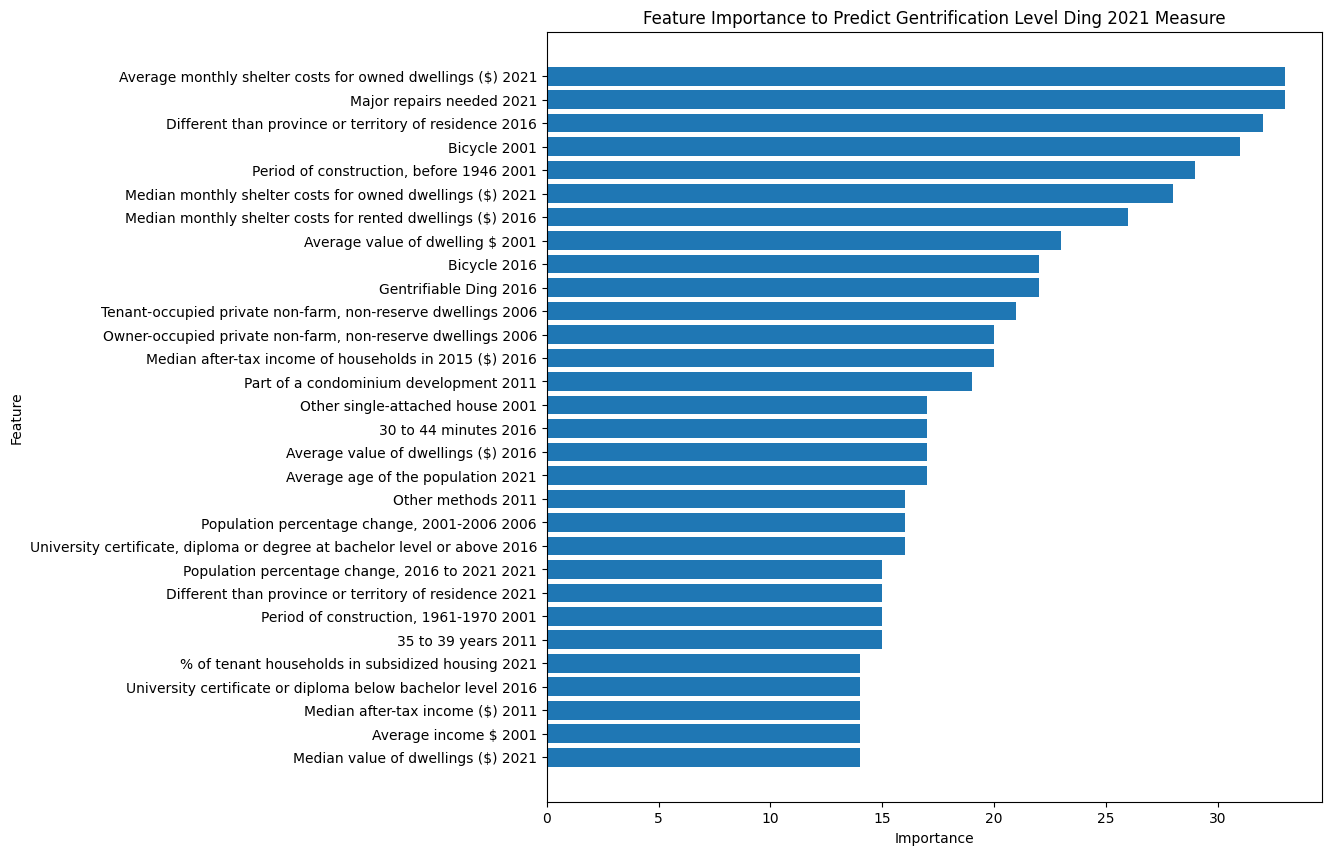

In [6]:
# Extract and plot feature importance
importance = bst.get_score(importance_type='weight')
importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(importance_df['Feature'].iloc[:30], importance_df['Importance'].iloc[:30])
plt.xlabel('Importance')
plt.ylabel('Feature')

# change title for each target
plt.title(f'Feature Importance to Predict {target_column} Measure')
plt.gca().invert_yaxis()

# Save the plot as an image file to Google Drive
plt.savefig(f'/content/drive/My Drive/GentrificAItion/ModelOutputs/feat_imp_2021_{target_column}.png', bbox_inches='tight')
plt.show()
plt.close('all')

# 2 Train Model to Predict Gentrification for 2021

In [3]:
# Specify columns we wish the model to predict
target_column_gentrifiable_2021 = "Gentrifiable Ding 2021"
target_column_gentrified_2021 = "Gentrified Ding 2021"
target_column_gen_levels_2021 = "Gentrification Level Ding 2021"

In [4]:
# Specify which column we wish the model to predict
target_column, num_class = target_column_gentrifiable_2021, 2
# target_column, num_class = target_column_gentrified_2021, 2
# target_column, num_class = target_column_gen_levels_2021, 4

In [5]:
# Specifify columns we wish to drop
columns_to_drop = [col for col in df.columns if col.endswith('2021') and col != target_column]

# Drop the columns
df_2 = df.drop(columns=columns_to_drop)
df_2 = df_2.drop(columns="ctuid")

print(df_2.head())

   50 to 59 years 2001  All others 2001  \
0                  0.0              0.0   
1                 40.0           2180.0   
2                140.0           2275.0   
3                140.0           2275.0   
4                135.0           5435.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                              290.0           
2                                              270.0           
3                                              270.0           
4                                              510.0           

   Average gross rent 2001  Average value dwelling 2001  \
0                      0.0                          0.0   
1                    440.0                        440.0   
2                    435.0                        435.0   
3                    435.0                        435.0   
4                   1105.0                       1105.0   

 

In [8]:
# Define features and target
X = df_2.drop(target_column, axis=1)
y = df_2[target_column]
print(X)
print(y)

      50 to 59 years 2001  All others 2001  \
0                0.000000          0.00000   
1               40.000000       2180.00000   
2              140.000000       2275.00000   
3              140.000000       2275.00000   
4              135.000000       5435.00000   
...                   ...              ...   
1003            51.290289       2965.82438   
1004            51.290289       2965.82438   
1005            51.290289       2965.82438   
1006            51.290289       2965.82438   
1007            51.290289       2965.82438   

      Apartment, building that has fewer than five storeys 2001  \
0                                              0.000000           
1                                            290.000000           
2                                            270.000000           
3                                            270.000000           
4                                            510.000000           
...                                          

In [9]:
import pickle

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix (XGBoost's internal data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters
params = {
    'objective': 'multi:softprob',  # Specify multiclass classification
    'num_class': num_class,  # NUMBER OF CLASSES
    'eval_metric': 'mlogloss',  # Evaluation metric
    'max_depth': 4,  # Maximum depth of a tree
    'eta': 0.3,  # Learning rate
    'seed': 42  # Random seed for reproducibility
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Save the model CHANGE NAME
with open(f'/content/drive/My Drive/GentrificAItion/ModelOutputs/{target_column}.pkl', 'wb') as f:
    pickle.dump(bst, f)

# Make predictions
y_pred_prob = bst.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.96


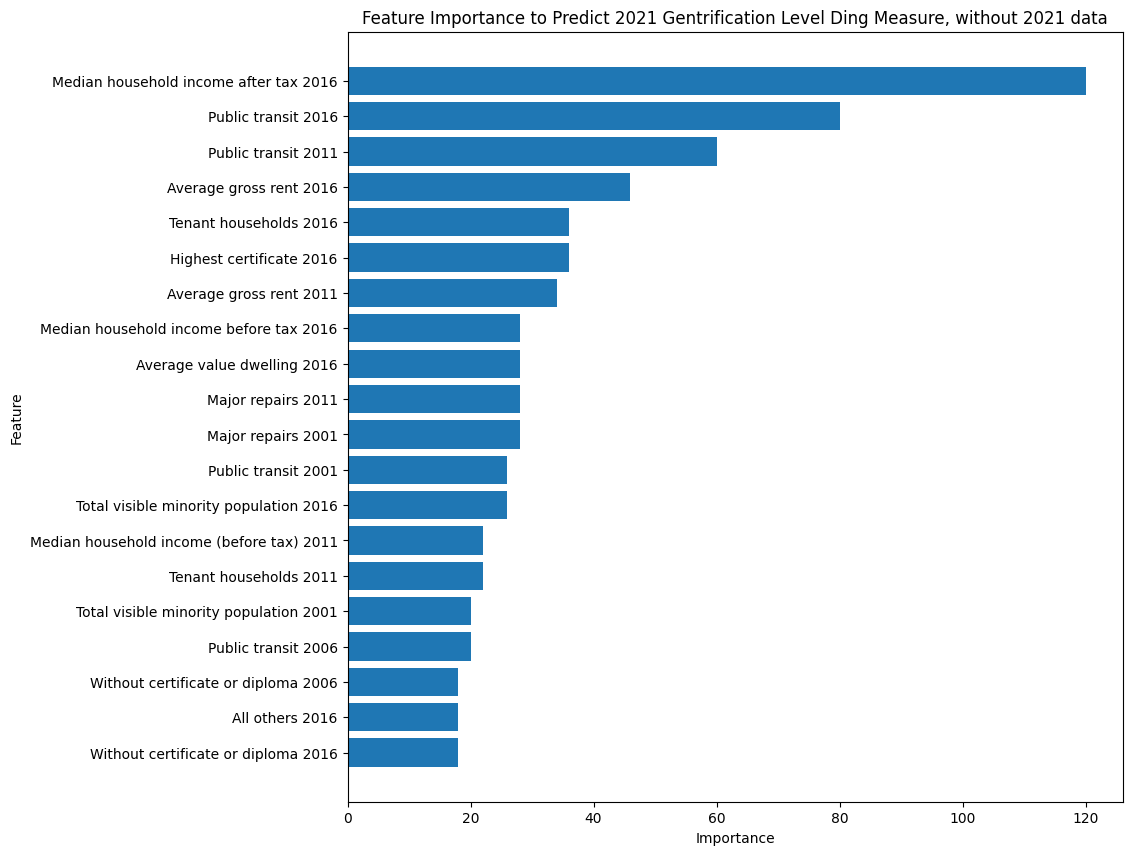

In [11]:
# Extract and plot feature importance
importance = bst.get_score(importance_type='weight')
importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(importance_df['Feature'].iloc[:20], importance_df['Importance'].iloc[:20])
plt.xlabel('Importance')
plt.ylabel('Feature')

# change title for each target
plt.title(f'Feature Importance to Predict {target_column} Measure, without 2021 data')
plt.gca().invert_yaxis()

# Save the plot as an image file to Google Drive
plt.savefig(f'/content/drive/My Drive/GentrificAItion/ModelOutputs/feat_imp_2021_no2021_{target_column}.png', bbox_inches='tight')
plt.show()
plt.close('all')

In [11]:
# Load the model for 2026 prediction

with open(f'/content/drive/My Drive/GentrificAItion/ModelOutputs/{target_column}.pkl', 'rb') as f: # change name based on prediction target
    loaded_model = pickle.load(f)


# 3 Predict Gentrification for 2026

In [10]:
# Replace 'your_dataset.csv' with your actual dataset file path
df = pd.read_csv('/content/drive/MyDrive/GentrificAItion/ModelOutputs/features_test.csv')

# Convert non-numeric values to NaN in each column
columns_to_convert = df.keys()
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values with the average
for col in columns_to_convert:
    average_value = df[col].mean()
    df[col].fillna(average_value, inplace=True)

# Convert specific columns to float
df[columns_to_convert] = df[columns_to_convert].astype(float)

# Display the updated dataset
print(df.head())

       ctuid  50 to 59 years 2001  All others 2001  \
0       -1.0                  0.0              0.0   
1  4620001.0                 15.0           2080.0   
2  4620002.0                 65.0           2290.0   
3  4620002.0                 65.0           2290.0   
4  4620003.0                 95.0           5410.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                              280.0           
2                                              360.0           
3                                              360.0           
4                                              925.0           

   Average gross rent 2001  Average value dwelling 2001  \
0                      0.0                          0.0   
1                    720.0                        525.0   
2                    785.0                        555.0   
3                    785.0                        555.

In [13]:
# Specify columns we wish the model to predict
gentrifiable_2026 = "Gentrifiable Ding 2026"
gentrified_2026 = "Gentrified Ding 2026"
gen_levels_2026 = "Gentrification Level Ding 2026"

In [14]:
# Define features by dropping all 2021 columns
X = df.drop(columns='ctuid')
dtest = xgb.DMatrix(X)

# Make predictions
y_pred_prob = loaded_model.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Add the predictions to the DataFrame
df[gentrifiable_2026] = y_pred

# Display the DataFrame with the new column
print(df.head())

       ctuid  50 to 59 years 2001  All others 2001  \
0       -1.0                  0.0              0.0   
1  4620001.0                 15.0           2080.0   
2  4620002.0                 65.0           2290.0   
3  4620002.0                 65.0           2290.0   
4  4620003.0                 95.0           5410.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                              280.0           
2                                              360.0           
3                                              360.0           
4                                              925.0           

   Average gross rent 2001  Average value dwelling 2001  \
0                      0.0                          0.0   
1                    720.0                        525.0   
2                    785.0                        555.0   
3                    785.0                        555.

<ipython-input-14-789345a4842f>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[gentrifiable_2026] = y_pred
